## Google colab GPU

In [5]:
# Colab: clone repo + add to path
import os
import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/colinminini/LLM6G-Repository'
REPO_DIR = 'LLM6G-Repository'

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.check_call(['git', 'clone', REPO_URL])
    os.chdir(REPO_DIR)
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())
else:
    print('Repo clone skipped (not running in Colab).')

HAS_CUDA = False
try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
except Exception:
    pass

if IN_COLAB and HAS_CUDA:
    # Install dependencies only when running on Colab with GPU
    !pip -q install -U pip
    !pip -q install -r requirements.txt
    # Optional: verify GPU
    !nvidia-smi
else:
    print(f'GPU setup skipped (colab={IN_COLAB}, cuda={HAS_CUDA}).')


Tue Feb  3 18:20:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P0             29W /   70W |     316MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Model Benchmarking (Coverage)

Train LSTM, DeepAR, and TFT on `data_1to7`, then fine-tune Chronos-2 on the same dataset. The summary reports coverage on train/val/test and plots the 0.8 one-step coverage target.


In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts.train_utils import train_all
from scripts.chronos2_finetune import (
    Chronos2FineTuneConfig,
    build_default_hyperparameters,
    load_splits_for_autogluon,
    run_chronos2_finetune,
    evaluate_chronos2_models,
)

MODEL_TYPES = ["lstm", "deepar", "tft"]
DATASET = "data_1to7"
SPLITS = ["train", "val", "test"]

CONTEXT_LENGTH = 16
FORECAST_LENGTH = 1
QUANTILES = (0.1, 0.5, 0.9)
MAX_EPOCHS = 100
PATIENCE = 3
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_HEADS = 4
COVERAGE_TARGET = 0.8

AUTOGLUON_TIME_LIMIT = 3000  # seconds
AUTOGLUON_EVAL_METRIC = "RMSE"
AUTOGLUON_FREQ = "s"  # synthetic regular cadence
AUTOGLUON_KNOWN_COVARIATES = []

RESULTS_DIR = Path("results/benchmarks")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHRONOS2_CONFIG = Chronos2FineTuneConfig(
    dataset_base=DATASET,
    prediction_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
    freq=AUTOGLUON_FREQ,
    use_integer_timestamps=True,
    synthetic_start="2000-01-01 00:00:00",
    eval_metric=AUTOGLUON_EVAL_METRIC,
    time_limit=AUTOGLUON_TIME_LIMIT,
    known_covariates_names=AUTOGLUON_KNOWN_COVARIATES,
    results_dir=RESULTS_DIR,
    hyperparameters=build_default_hyperparameters(),
    #hyperparameters={"Chronos2": {"fine_tune": True, "fine_tune_mode": "full", 
    #                              "fine_tune_lr": 1e-4, "fine_tune_steps": 2000, "fine_tune_batch_size": 32}},
)


## Train baseline models

This runs LSTM, DeepAR, and TFT on `data_1to7`. Coverage shown is the final epoch value returned by the trainer.


In [5]:
train_results, train_histories = train_all(
    MODEL_TYPES,
    DATASET,
    context_length=CONTEXT_LENGTH,
    forecast_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
)

train_rows = []
for (dataset, model), metrics in train_results.items():
    for split, coverage in metrics.items():
        train_rows.append(
            {"dataset": dataset, "split": split, "model": model, "coverage": coverage}
        )

train_df = pd.DataFrame(train_rows)
train_pivot = train_df.pivot_table(
    index=["dataset", "split"], columns="model", values="coverage"
).sort_index()
train_pivot


Epoch 1/100 - train_loss=0.452 - train_rmse=3.335 - val_loss=0.679 - val_rmse=4.553 - test_loss=0.720 - test_rmse=4.931 
Epoch 2/100 - train_loss=0.386 - train_rmse=2.857 - val_loss=0.643 - val_rmse=4.436 - test_loss=0.672 - test_rmse=4.725 
Epoch 3/100 - train_loss=0.377 - train_rmse=2.868 - val_loss=0.632 - val_rmse=4.462 - test_loss=0.664 - test_rmse=4.664 
Epoch 4/100 - train_loss=0.374 - train_rmse=2.831 - val_loss=0.626 - val_rmse=4.367 - test_loss=0.657 - test_rmse=4.642 
Epoch 5/100 - train_loss=0.371 - train_rmse=2.813 - val_loss=0.624 - val_rmse=4.421 - test_loss=0.654 - test_rmse=4.632 
Early stopping at epoch 6: train_rmse=2.829, val_rmse=4.333, test_rmse=4.625


'Final metrics'

,metric,value
0,train_loss,0.370
1,train_rmse,2.829
2,val_loss,0.621
3,val_rmse,4.333
4,train_q0.1,0.171
5,train_q0.5,0.670
6,train_q0.9,0.269
7,val_q0.1,0.294
8,val_q0.5,1.142
9,val_q0.9,0.436


Epoch 1/100 - train_loss=1.788 - train_rmse=2.580 - val_loss=2.246 - val_rmse=3.962 - test_loss=2.323 - test_rmse=4.186 
Epoch 2/100 - train_loss=1.692 - train_rmse=2.489 - val_loss=2.190 - val_rmse=3.932 - test_loss=2.265 - test_rmse=4.141 
Epoch 3/100 - train_loss=1.632 - train_rmse=2.471 - val_loss=2.165 - val_rmse=3.945 - test_loss=2.209 - test_rmse=4.153 
Early stopping at epoch 4: train_rmse=2.462, val_rmse=3.957, test_rmse=4.163


'Final metrics'

,metric,value
0,train_loss,1.633
1,train_rmse,2.462
2,val_loss,2.188
3,val_rmse,3.957
4,train_q0.1,0.255
5,train_q0.5,0.804
6,train_q0.9,0.306
7,val_q0.1,0.424
8,val_q0.5,1.365
9,val_q0.9,0.499


Epoch 1/100 - train_loss=0.420 - train_rmse=3.060 - val_loss=0.646 - val_rmse=4.598 - test_loss=0.687 - test_rmse=4.947 
Epoch 2/100 - train_loss=0.381 - train_rmse=2.893 - val_loss=0.631 - val_rmse=4.486 - test_loss=0.661 - test_rmse=4.717 
Epoch 3/100 - train_loss=0.374 - train_rmse=2.844 - val_loss=0.615 - val_rmse=4.409 - test_loss=0.640 - test_rmse=4.661 
Epoch 4/100 - train_loss=0.371 - train_rmse=2.839 - val_loss=0.606 - val_rmse=4.372 - test_loss=0.637 - test_rmse=4.626 
Epoch 5/100 - train_loss=0.368 - train_rmse=2.833 - val_loss=0.614 - val_rmse=4.456 - test_loss=0.644 - test_rmse=4.736 
Epoch 6/100 - train_loss=0.368 - train_rmse=2.829 - val_loss=0.608 - val_rmse=4.463 - test_loss=0.639 - test_rmse=4.760 
Epoch 7/100 - train_loss=0.367 - train_rmse=2.836 - val_loss=0.605 - val_rmse=4.482 - test_loss=0.634 - test_rmse=4.740 
Epoch 8/100 - train_loss=0.365 - train_rmse=2.832 - val_loss=0.609 - val_rmse=4.460 - test_loss=0.639 - test_rmse=4.758 
Early stopping at epoch 9: train

'Final metrics'

,metric,value
0,train_loss,0.364
1,train_rmse,2.831
2,val_loss,0.608
3,val_rmse,4.469
4,train_q0.1,0.171
5,train_q0.5,0.654
6,train_q0.9,0.268
7,val_q0.1,0.294
8,val_q0.5,1.107
9,val_q0.9,0.429


model              deepar      lstm       tft
dataset   split                              
data_1to7 test   0.825346  0.460183  0.935753
          train  0.847535  0.799683  0.799502
          val    0.830749  0.454428  0.934931

## AutoGluon Chronos-2 fine-tuning

We fine-tune Chronos-2 using AutoGluon TimeSeries with a zero-shot and fine-tuned run.


In [4]:
train_data, val_data, test_data, data_freq = load_splits_for_autogluon(CHRONOS2_CONFIG)

predictor, model_names, leaderboard = run_chronos2_finetune(
    CHRONOS2_CONFIG,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    freq=data_freq,
)

autogluon_df = evaluate_chronos2_models(
    predictor,
    model_names=model_names,
    splits={"train": train_data, "val": val_data, "test": test_data},
    dataset_label=DATASET,
    prediction_length=FORECAST_LENGTH,
    quantiles=QUANTILES,
)

autogluon_coverage_pivot = autogluon_df.pivot_table(
    index=["dataset", "split"], columns="model", values="coverage"
).sort_index()
autogluon_rmse_pivot = autogluon_df.pivot_table(
    index=["dataset", "split"], columns="model", values="rmse"
).sort_index()

autogluon_coverage_pivot, autogluon_rmse_pivot, leaderboard


Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/benchmarks/autogluon_data_1to7'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.7
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:08:48 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T8132
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       5.26 GB / 16.00 GB (32.9%)
Disk Space Avail:   333.50 GB / 460.43 GB (72.4%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': RMSE,
 'freq': 's',
 'hyperparameters': {'Chronos2': [{'ag_args': {'name_suffix': 'ZeroShot'}},
                                  {'ag_args': {'name_suffix': 'FineTuned'},
                       

(model            autogluon_Chronos2FineTuned  autogluon_Chronos2ZeroShot
 dataset   split                                                         
 data_1to7 test                      0.825581                    0.813953
           train                     0.662791                    0.639535
           val                       0.848837                    0.837209,
 model            autogluon_Chronos2FineTuned  autogluon_Chronos2ZeroShot
 dataset   split                                                         
 data_1to7 test                      4.002990                    4.012577
           train                     3.734129                    3.719271
           val                       4.048438                    4.084828,
                model  score_test  score_val  pred_time_test  pred_time_val  \
 0  Chronos2FineTuned   -4.002990  -3.757214        0.755499       0.418947   
 1   Chronos2ZeroShot   -4.012577  -4.084828        0.770395       0.423153   
 
    fit_time_margin

## Coverage and RMSE comparison summary

This table and plot compare coverage across train/val/test for all models.
The AutoGluon tables above include both coverage and RMSE for Chronos-2
ZeroShot vs FineTuned.


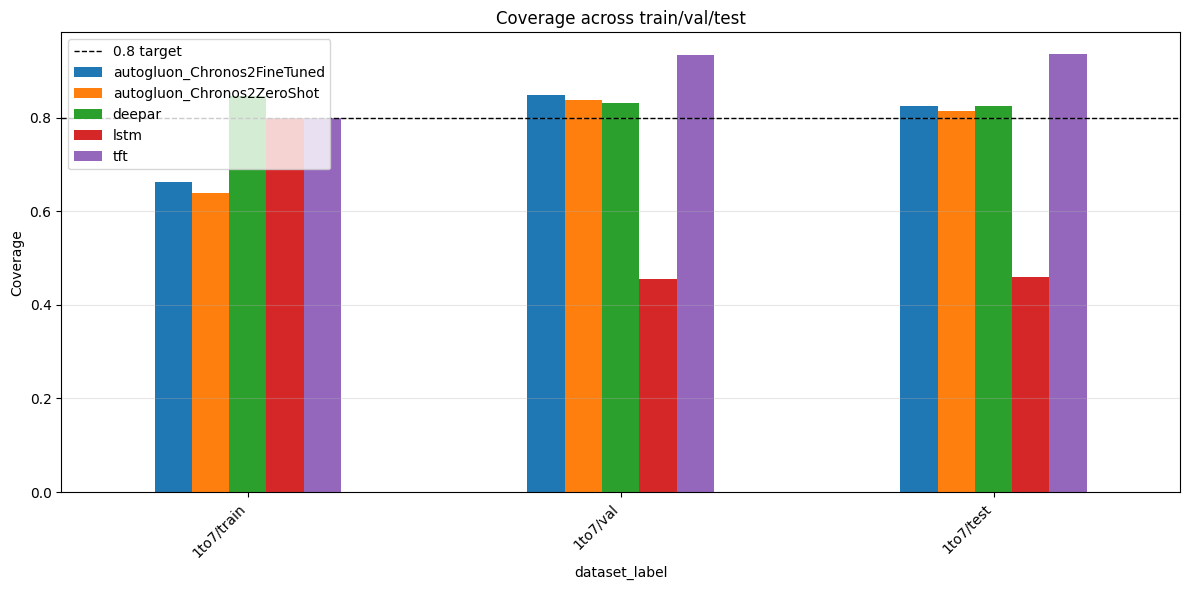

model            autogluon_Chronos2FineTuned  autogluon_Chronos2ZeroShot
dataset   split                                                         
data_1to7 test                      4.002990                    4.012577
          train                     3.734129                    3.719271
          val                       4.048438                    4.084828

In [6]:
summary_df = pd.concat(
    [train_df, autogluon_df[["dataset", "split", "model", "coverage"]]],
    ignore_index=True,
)
summary_df["dataset_label"] = summary_df["dataset"].str.replace("data_", "") + "/" + summary_df["split"]
order = [
    "1to7/train",
    "1to7/val",
    "1to7/test",
]

summary_pivot = summary_df.pivot_table(
    index="dataset_label", columns="model", values="coverage"
).reindex(order)
summary_pivot  # type: ignore

ax = summary_pivot.plot(kind="bar", figsize=(12, 6))
ax.axhline(COVERAGE_TARGET, color="black", linestyle="--", linewidth=1, label="0.8 target")
ax.set_ylabel("Coverage")
ax.set_title("Coverage across train/val/test")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

autogluon_rmse_pivot
